# TOPFIM — Topography-Based Real-Time Flood Inundation Mapping
### A hands-on implementation notebook

|  |  |
|---|---|
| **Instructor** | Siddik — HIMPACT Lab, Indian Institute of Technology Mandi |
| **Method source** | Shi, P., *et al.* (2025), *A Novel Topography-Based Approach for Real-Time Flood Inundation Mapping*, **Water Resources Research**, 61, e2024WR037851. <https://doi.org/10.1029/2024WR037851> |
| **Companion dataset** | Shi, P. (2024), *The code and data for TOPFIM*, figshare. <https://doi.org/10.6084/m9.figshare.25687194> |

---

### Why this notebook exists

Hydrodynamic models (HEC-RAS, LISFLOOD-FP, TELEMAC, SRH-2D) solve the shallow-water
equations and give you the *right* answer — eventually. On a large basin at fine
resolution, "eventually" can mean hours. That is fatal for **impact-based flood
forecasting**, where a map is only useful if it arrives before the water does.

TOPFIM belongs to the family of **low-complexity, terrain-based** inundation models.
It throws away momentum entirely and keeps only two things: the **shape of the
terrain** (encoded as HAND) and a hard **mass-conservation constraint**. The paper
reports a mean Critical Success Index of about 0.83 against a HEC-RAS benchmark on
the upper Le'an River basin, China — at a small fraction of the runtime.

This notebook rebuilds that idea **from first principles, in pure NumPy**, so that you
understand every line rather than calling a black box.

> ### Read this before you start — provenance and scope
>
> **1. This is a teaching reimplementation, not the authors' code.**
> The notebook reconstructs the TOPFIM *algorithm* from the published method
> description (modules M1–M4, the RIC segmentation concept, the CIN allocation
> concept, the Synthetic Volume Curve). It is written to be **transparent and
> pedagogically faithful**, not bit-identical to the authors' scripts. Where the
> published paper states a concept but this notebook must commit to a specific
> equation, you will see a box like this:
>
> > ⚠️ **Operational definition.** *This is the notebook's chosen formulation.
> > Check it against the paper's equations before using it in your own research.*
>
> **2. The Figshare archive was not machine-readable at authoring time.**
> The Figshare landing page blocks automated access, so the exact file manifest
> (`.tif` names, folder layout, units, CRS) could not be inspected while writing
> this. Section 3 therefore gives you (a) a **live loader** that queries the
> Figshare API from your own machine, and (b) a **synthetic basin generator** so
> the notebook runs end-to-end today with zero downloads. Whichever you use, the
> algorithm code in Sections 4–7 is identical.
>
> **3. Do not report results from the synthetic basin as if they were the
> Le'an River results.** The synthetic basin is a controlled sandbox for learning
> the mechanics. Real validation requires the real DEM and the real HEC-RAS
> benchmark maps.
>
> Being explicit about what you know, what you assumed, and what you could not
> verify **is** the scientific method. Carry that habit into your own papers.

## 1. Learning objectives

By the end of this notebook you should be able to:

1. **Explain** why terrain-based inundation models are fast, and precisely what
   physics they discard to buy that speed.
2. **Implement** the standard DEM-hydrology chain from scratch: depression filling
   (Priority-Flood), D8 flow direction, flow accumulation, channel extraction.
3. **Compute** the HAND (Height Above Nearest Drainage) raster and the
   **Flood-Prone Area (FPA)** membership map that pairs every hillslope cell with
   its controlling river cell.
4. **Construct** a stage–volume relationship (the **Synthetic Volume Curve**, SVC)
   and understand why it must be monotone.
5. **Segment** a river network adaptively using a topographic capacity metric
   (**RIC**) instead of arbitrary fixed-length reaches.
6. **Allocate** a known flood volume across segments under a **full water-volume
   constraint**, and invert each SVC to obtain a segment stage.
7. **Evaluate** a binary inundation map with CSI, POD (hit rate), FAR and bias, and
   read a contingency map.
8. **Critique** the method: state at least three failure modes where you would
   refuse to use TOPFIM and reach for a hydrodynamic model instead.

### Prerequisites

- Open-channel hydraulics: stage, discharge, conveyance, rating curves (CE-452 level).
- Python: NumPy array indexing, `matplotlib`, basic functions. No GIS software needed.
- Helpful but not required: prior exposure to HEC-RAS or any 2-D hydraulic model.

## 2. Background — where TOPFIM sits

### 2.1 The speed/fidelity trade-off

| Family | Physics solved | Typical cost | Example |
|---|---|---|---|
| Full 2-D shallow water | Mass + momentum, inertia, friction | Hours–days | HEC-RAS 2D, TELEMAC-2D |
| Local-inertial / diffusive | Mass + simplified momentum | Minutes–hours | LISFLOOD-FP |
| **Terrain-based (this notebook)** | **Mass only**, geometry from DEM | **Seconds** | HAND, SRC-HAND, **TOPFIM** |
| Data-driven surrogates | Learned mapping | Seconds (after training) | CNN / GNN emulators |

Terrain-based methods assume the water surface within a small region is
**horizontal**. Under that assumption you do not need momentum: you need to know,
for a given water-surface elevation, *which cells are below it and by how much*.
That is exactly what HAND gives you.

### 2.2 HAND in one sentence

> **HAND** of a cell = its elevation minus the elevation of the river cell it
> drains into along the D8 flow path.

So HAND is a **local**, drainage-referenced vertical coordinate. A cell with
$\mathrm{HAND}=1.5$ m sits 1.5 m above its own bit of river — whether that river
is at 900 m in the Himalaya or 20 m in the Gangetic plain. This is what makes a
single depth threshold meaningful across a whole basin, which raw elevation never
could be.

### 2.3 What plain HAND gets wrong, and what TOPFIM adds

Classic HAND flooding says: *pick a depth $h$, flood every cell with
$\mathrm{HAND} < h$.* Three problems:

1. **$h$ comes from nowhere.** It is a tuning knob, not a physical quantity.
2. **One $h$ for the whole basin.** A headwater tributary and the trunk river get
   the same stage, which is obviously wrong.
3. **Water is not conserved.** Nothing forces the mapped water volume to equal the
   flood volume actually delivered by the hydrograph.

TOPFIM attacks all three, through four modules:

```
   ┌──────────────────────────────────────────────────────────────────────┐
   │  M1  DEM ─► fill ─► D8 ─► flow accumulation ─► river network ─► HAND │
   │      └► also: FPA map (which river cell "owns" each hillslope cell)  │
   ├──────────────────────────────────────────────────────────────────────┤
   │  M2  For each river cell, characterise its FPA's storage geometry    │
   │      ─► River Inundation Capacity (RIC)                              │
   ├──────────────────────────────────────────────────────────────────────┤
   │  M3  Walk the network; merge consecutive river cells with SIMILAR    │
   │      RIC into a SEGMENT  ─► adaptive (not fixed-length) segmentation │
   ├──────────────────────────────────────────────────────────────────────┤
   │  M4  Split total flood volume V among segments (CIN weights θ),      │
   │      Σ Vⱼ = V exactly;  invert each segment's Synthetic Volume Curve │
   │      to get its stage hⱼ  ─► depth & extent map                      │
   └──────────────────────────────────────────────────────────────────────┘
```

The key inversion of logic: **classic HAND starts from a depth and produces a
volume. TOPFIM starts from a volume and produces a depth.** Volume is the thing a
hydrological model can actually forecast, so this is the more useful direction.

### 2.4 The mathematics you will implement

**Synthetic Volume Curve (SVC).** For a segment $j$ whose flood-prone area
$\Omega_j$ contains cells of plan area $A_c=\Delta x^2$, the stored volume at
stage $h$ (measured as a HAND value) is

$$
V_j(h) \;=\; A_c \sum_{c \in \Omega_j} \max\!\left(0,\; h - \mathrm{HAND}_c\right)
$$

and the inundated area is

$$
A_j(h) \;=\; A_c \cdot \#\{\, c \in \Omega_j \;:\; \mathrm{HAND}_c < h \,\}.
$$

$V_j$ is continuous, non-decreasing and piecewise quadratic in $h$ — so it is
**invertible**. Note that $\mathrm{d}V_j/\mathrm{d}h = A_j(h)$, exactly the
hypsometric relationship you would expect. This is the volumetric analogue of the
Synthetic Rating Curve (SRC) used in the NOAA/OWP HAND-FIM framework, except it
maps *volume* rather than *discharge* to stage — which is why no Manning's $n$ and
no channel slope appear anywhere in this notebook.

**Full water-volume constraint.** Given a total flood volume $V$ and allocation
weights $\theta_j$ with $\sum_j \theta_j = 1$:

$$
V_j = \theta_j V, \qquad h_j = V_j^{-1}(\theta_j V), \qquad
\sum_j V_j(h_j) = V .
$$

**Depth field.** Cell $c$ belonging to segment $j$ is wet iff
$\mathrm{HAND}_c < h_j$, with depth $d_c = h_j - \mathrm{HAND}_c$.

Notice the consequence, which the TOPFIM authors themselves flag as a limitation:
**every cell in a segment is referenced to the same stage $h_j$.** Extent is
therefore modelled much better than depth. Keep this in mind at evaluation time.

---
## 3. Environment setup

The core of this notebook needs only **NumPy**, **SciPy** and **Matplotlib** — the
whole terrain-hydrology chain is implemented from scratch. `rasterio` is optional
and is used only if you point the notebook at real GeoTIFFs.

In [1]:
# If anything is missing, uncomment:
# %pip install numpy scipy matplotlib
# %pip install rasterio requests      # optional: real GeoTIFF I/O + Figshare download

import sys, math, heapq, json, time, warnings
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "image.interpolation": "nearest",
})

HAS_RASTERIO = False
try:
    import rasterio
    HAS_RASTERIO = True
except ImportError:
    pass

print(f"Python   {sys.version.split()[0]}")
print(f"NumPy    {np.__version__}")
print(f"rasterio {'available' if HAS_RASTERIO else 'NOT installed (optional)'}")

Python   3.12.3
NumPy    2.4.4
rasterio NOT installed (optional)


---
## 4. Getting the data

### 4.1 Option A — the real TOPFIM archive from Figshare

The companion archive is **"The code and data for TOPFIM"**,
DOI `10.6084/m9.figshare.25687194`. The cell below queries the **public Figshare
REST API** (no token needed) and prints the file manifest, so you can see exactly
what is in there before downloading anything.

> **Note.** This was written without being able to inspect the archive
> programmatically — the Figshare landing page blocks automated agents. Run the
> cell yourself: it will print the *actual* manifest. Expect DEM rasters for the
> upper Le'an River basin (the paper uses both **5 m** and **30 m** DEMs), the
> HEC-RAS benchmark inundation maps, and hydrograph/boundary-condition files for
> events including **24 June 2017**.

In [2]:
FIGSHARE_ARTICLE_ID = 25687194
API = "https://api.figshare.com/v2/articles/{}"

def figshare_manifest(article_id=FIGSHARE_ARTICLE_ID, timeout=30):
    """List files in a public Figshare article. Returns (metadata, files)."""
    import requests
    r = requests.get(API.format(article_id), timeout=timeout)
    r.raise_for_status()
    meta = r.json()
    return meta, meta.get("files", [])

try:
    meta, files = figshare_manifest()
    print(f"Title   : {meta.get('title')}")
    print(f"DOI     : {meta.get('doi')}")
    print(f"Authors : {', '.join(a['full_name'] for a in meta.get('authors', []))}")
    print(f"License : {meta.get('license', {}).get('name')}")
    print(f"\n{len(files)} file(s):")
    for f in files:
        print(f"  {f['name']:<55} {f['size']/1e6:>10.2f} MB   {f['download_url']}")
except Exception as e:
    print(f"[!] Could not reach Figshare ({type(e).__name__}: {e})")
    print("    No problem — Section 4.2 builds a synthetic basin so the notebook")
    print("    still runs end-to-end. Download manually from:")
    print("    https://doi.org/10.6084/m9.figshare.25687194")

[!] Could not reach Figshare (HTTPError: 403 Client Error: Forbidden for url: https://api.figshare.com/v2/articles/25687194)
    No problem — Section 4.2 builds a synthetic basin so the notebook
    still runs end-to-end. Download manually from:
    https://doi.org/10.6084/m9.figshare.25687194


In [3]:
from pathlib import Path

DATA_DIR = Path("topfim_data"); DATA_DIR.mkdir(exist_ok=True)

def figshare_download(files, pattern=None, out_dir=DATA_DIR, chunk=1 << 20):
    """Download files whose name contains `pattern` (None = all). Skips existing."""
    import requests
    got = []
    for f in files:
        if pattern and pattern.lower() not in f["name"].lower():
            continue
        dst = out_dir / f["name"]
        if dst.exists() and dst.stat().st_size == f["size"]:
            print(f"  cached  {f['name']}"); got.append(dst); continue
        print(f"  fetching {f['name']} ({f['size']/1e6:.1f} MB) ...", end=" ", flush=True)
        with requests.get(f["download_url"], stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(dst, "wb") as fh:
                for blk in r.iter_content(chunk):
                    fh.write(blk)
        print("done"); got.append(dst)
    return got

# --- Uncomment to actually download (archive may be large) -------------------
# paths = figshare_download(files)                 # everything
# paths = figshare_download(files, pattern=".zip") # or filter by name

### 4.2 Option B — a synthetic basin (always works)

For learning the algorithm, a controlled synthetic basin is arguably *better* than
real data: you know the ground truth geometry, it runs in seconds, and nothing is
hidden behind a projection or a NoData mask.

Our test basin is a **meandering valley** with:

- a broad, nearly flat **floodplain** (±300 m from the channel centreline),
- steeper **hillslopes** beyond it,
- a gentle **downstream gradient** (0.25 %),
- correlated **micro-topography** so that the DEM is not artificially smooth.

This geometry gives a genuinely non-uniform RIC along the river — which is the
whole point of TOPFIM's adaptive segmentation, and which a straight rectangular
channel would completely fail to exercise.

In [4]:
from scipy.ndimage import gaussian_filter

def synthetic_basin(nrows=120, ncols=180, cellsize=30.0, seed=7,
                    fp_halfwidth=300.0, fp_relief=3.0,
                    hill_slope=0.030, long_slope=0.0025,
                    meander_amp=0.16, meander_wave=0.55, roughness=3.0):
    """A meandering-valley DEM. Returns (dem [m], cellsize [m])."""
    rng = np.random.default_rng(seed)
    X, Y = np.meshgrid(np.arange(ncols) * cellsize, np.arange(nrows) * cellsize)

    centreline = Y.mean() + meander_amp * Y.max() * np.sin(2*np.pi*X / (meander_wave*X.max()))
    dist = np.abs(Y - centreline)

    floodplain = fp_relief * np.minimum(dist, fp_halfwidth) / fp_halfwidth
    hillslope  = hill_slope * np.maximum(dist - fp_halfwidth, 0.0)
    trend      = -long_slope * X

    dem = 260.0 + trend + floodplain + hillslope
    dem += gaussian_filter(rng.normal(0, 1, (nrows, ncols)), 2.0) * roughness
    return dem.astype("float64"), cellsize


def load_dem_geotiff(path):
    """Read band 1 of a GeoTIFF. Returns (dem, cellsize, profile)."""
    if not HAS_RASTERIO:
        raise ImportError("pip install rasterio")
    with rasterio.open(path) as src:
        dem = src.read(1).astype("float64")
        if src.nodata is not None:
            dem[dem == src.nodata] = np.nan
        return dem, float(abs(src.transform.a)), src.profile


# ---- CHOOSE YOUR SOURCE ------------------------------------------------------
USE_REAL_DEM = False          # flip to True once you have a DEM on disk
DEM_PATH     = DATA_DIR / "dem.tif"

if USE_REAL_DEM:
    dem, CELLSIZE, prof = load_dem_geotiff(DEM_PATH)
else:
    dem, CELLSIZE = synthetic_basin()

NROWS, NCOLS = dem.shape
CELL_AREA = CELLSIZE ** 2
print(f"DEM      {NROWS} x {NCOLS} cells @ {CELLSIZE:g} m  "
      f"({NROWS*NCOLS:,} cells, {NROWS*NCOLS*CELL_AREA/1e6:.1f} km2)")
print(f"Elevation {np.nanmin(dem):.1f} - {np.nanmax(dem):.1f} m  "
      f"(relief {np.nanmax(dem)-np.nanmin(dem):.1f} m)")

DEM      120 x 180 cells @ 30 m  (21,600 cells, 19.4 km2)
Elevation 246.7 - 323.1 m  (relief 76.4 m)


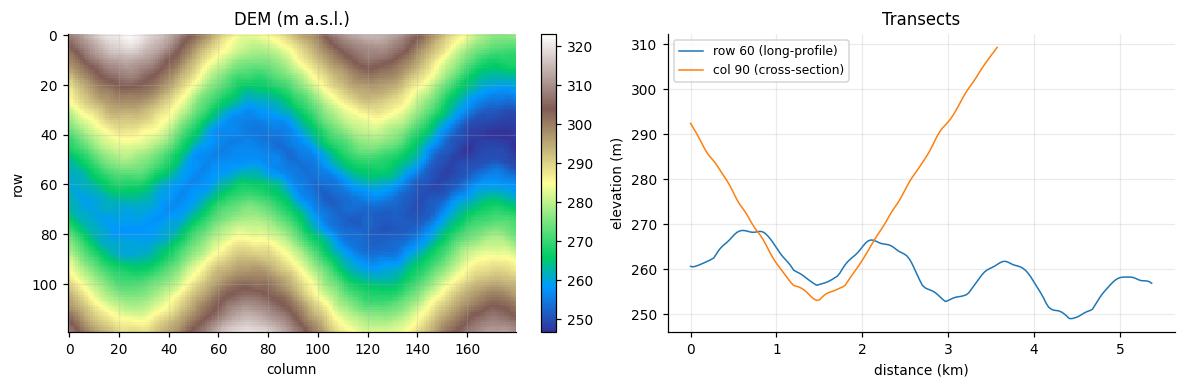

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

im = ax[0].imshow(dem, cmap="terrain")
ax[0].set_title("DEM (m a.s.l.)"); ax[0].set_xlabel("column"); ax[0].set_ylabel("row")
plt.colorbar(im, ax=ax[0], fraction=0.035)

mid = NROWS // 2
ax[1].plot(np.arange(NCOLS) * CELLSIZE / 1000, dem[mid], lw=1.0, label=f"row {mid} (long-profile)")
ax[1].plot(np.arange(NROWS) * CELLSIZE / 1000, dem[:, NCOLS//2], lw=1.0, label=f"col {NCOLS//2} (cross-section)")
ax[1].set_xlabel("distance (km)"); ax[1].set_ylabel("elevation (m)")
ax[1].legend(fontsize=8); ax[1].set_title("Transects")
plt.tight_layout(); plt.show()

---
## 5. Module M1 — DEM → flow direction → river network → HAND

This is the standard DEM-hydrology chain. Everything downstream depends on getting
it right, so we build each step explicitly and sanity-check it.

### 5.1 Depression filling (Priority-Flood)

Real and synthetic DEMs both contain **spurious pits** — single cells or hollows
with no downslope neighbour. They arise from interpolation error, vegetation
returns, bridges and culverts. A flow-routing algorithm reaching a pit simply
stops, tearing holes in the drainage network.

We use **Priority-Flood + ε** (Barnes, Lehman & Mulla, 2014). Intuition: imagine
flooding the DEM from its edges with a rising water surface, always processing the
lowest unprocessed cell first (a min-heap). Every cell is raised to at least the
level of the water that reached it. The tiny $\varepsilon$ increment guarantees a
strictly descending path exists everywhere, which removes flat-area ambiguity.

Complexity is $O(n \log n)$. In pure Python this is the slowest cell in the
notebook; for production work use `richdem`, `pysheds`, `WhiteboxTools` or
`TauDEM`.

In [6]:
# 8 neighbours, in ESRI D8 convention:
#   32  64 128          NW  N  NE
#   16   *   1     ==    W  *   E
#    8   4   2          SW  S  SE
D8_NEIGHBOURS = [( 0,  1,   1), ( 1,  1,   2), ( 1,  0,   4), ( 1, -1,   8),
                 ( 0, -1,  16), (-1, -1,  32), (-1,  0,  64), (-1,  1, 128)]


def fill_depressions(dem, eps=1e-4):
    """Priority-Flood + epsilon (Barnes et al., 2014, Computers & Geosciences).

    Returns a DEM with no interior pits and a strictly descending path from
    every cell to the domain edge.
    """
    dem = np.asarray(dem, dtype="float64")
    nr, nc = dem.shape
    filled = np.full_like(dem, np.inf)
    closed = np.zeros(dem.shape, dtype=bool)
    pq = []

    # Seed the heap with the domain boundary -- these are the outlets.
    for r in range(nr):
        for c in (0, nc - 1):
            heapq.heappush(pq, (dem[r, c], r, c)); closed[r, c] = True
    for c in range(nc):
        for r in (0, nr - 1):
            if not closed[r, c]:
                heapq.heappush(pq, (dem[r, c], r, c)); closed[r, c] = True

    while pq:
        z, r, c = heapq.heappop(pq)
        filled[r, c] = z
        for dr, dc, _ in D8_NEIGHBOURS:
            rr, cc = r + dr, c + dc
            if 0 <= rr < nr and 0 <= cc < nc and not closed[rr, cc]:
                closed[rr, cc] = True
                # raise the neighbour to at least z + eps
                heapq.heappush(pq, (max(dem[rr, cc], z + eps), rr, cc))
    return filled


t0 = time.time()
dem_filled = fill_depressions(dem)
dz = dem_filled - dem
print(f"Priority-Flood: {time.time()-t0:.2f} s")
print(f"cells raised : {(dz > 1e-9).sum():,} / {dz.size:,}  ({100*(dz>1e-9).mean():.2f} %)")
print(f"max fill     : {dz.max():.3f} m")

Priority-Flood: 0.05 s
cells raised : 274 / 21,600  (1.27 %)
max fill     : 0.932 m


> **Diagnostic habit.** Always look at *how much* filling happened. A few tenths of
> a metre over a small percentage of cells is normal noise removal. If you see
> metres of fill over large contiguous patches, your DEM has a real problem — a
> road embankment acting as a dam, a missing culvert, or a bad NoData mask — and
> filling it silently will move your river to the wrong place. **Breaching**
> (carving a channel through the blockage) is often the better fix.

### 5.2 D8 flow direction

Each cell drains entirely to the one neighbour of **steepest descent**, where slope
is measured per unit *distance* (so diagonals are divided by $\sqrt{2}$):

$$
S_k = \frac{z_0 - z_k}{\Delta x \cdot \sqrt{2}^{\,\mathbb{1}[\text{diagonal}]}}
$$

D8 is crude — it forces flow into 8 discrete directions and cannot represent
divergent flow on hillslopes. Alternatives (D-infinity, MFD) spread flow across
multiple neighbours. For *channel network extraction*, which is what we need here,
D8 is the standard choice precisely because its single-receiver property makes the
drainage network a **tree**, which we will exploit heavily in Sections 5.5 and 6.

We implement it twice: an explicit loop (readable) and a vectorised version
(fast). They are asserted to be identical.

In [7]:
def d8_flow_direction_loop(dem, cellsize=1.0):
    """Readable reference implementation. O(8n) but Python-slow."""
    nr, nc = dem.shape
    code_ = np.zeros((nr, nc), np.int32)
    receiver = np.full((nr, nc, 2), -1, np.int32)
    for r in range(nr):
        for c in range(nc):
            best, bcode, brc = 0.0, 0, (-1, -1)
            for dr, dc, k in D8_NEIGHBOURS:
                rr, cc = r + dr, c + dc
                if not (0 <= rr < nr and 0 <= cc < nc):
                    continue
                dist = cellsize * (math.sqrt(2) if (dr and dc) else 1.0)
                slope = (dem[r, c] - dem[rr, cc]) / dist
                if slope > best:
                    best, bcode, brc = slope, k, (rr, cc)
            code_[r, c], receiver[r, c] = bcode, brc
    return code_, receiver


def d8_flow_direction(dem, cellsize=1.0):
    """Vectorised. Identical output, ~40x faster."""
    nr, nc = dem.shape
    pad = np.pad(dem, 1, constant_values=np.inf)      # off-grid = infinitely high
    best = np.zeros((nr, nc))
    code_ = np.zeros((nr, nc), np.int32)
    rr_ = np.full((nr, nc), -1, np.int32)
    cc_ = np.full((nr, nc), -1, np.int32)
    R, C = np.meshgrid(np.arange(nr), np.arange(nc), indexing="ij")

    for dr, dc, k in D8_NEIGHBOURS:
        nb = pad[1+dr:1+dr+nr, 1+dc:1+dc+nc]
        dist = cellsize * (math.sqrt(2) if (dr and dc) else 1.0)
        slope = (dem - nb) / dist
        m = slope > best
        best[m], code_[m] = slope[m], k
        rr_[m], cc_[m] = (R + dr)[m], (C + dc)[m]

    off = (rr_ < 0) | (rr_ >= nr) | (cc_ < 0) | (cc_ >= nc)
    rr_[off] = cc_[off] = -1
    code_[off] = 0                                    # drains off the domain edge
    return code_, np.stack([rr_, cc_], axis=-1)


fdir, receiver = d8_flow_direction(dem_filled, CELLSIZE)

# --- verify the fast path against the readable one (small window) ------------
w = (slice(0, 40), slice(0, 40))
f_ref, r_ref = d8_flow_direction_loop(dem_filled[w], CELLSIZE)
f_fast, r_fast = d8_flow_direction(dem_filled[w], CELLSIZE)
assert (f_ref == f_fast).all(), "D8 codes disagree"
print("vectorised D8 verified against loop reference on a 40x40 window")
print(f"cells with no receiver (edge outlets): {(fdir == 0).sum()}")

vectorised D8 verified against loop reference on a 40x40 window
cells with no receiver (edge outlets): 1


### 5.3 Flow accumulation

Because D8 gives every cell exactly one receiver, the drainage network is a
**directed tree**. So we can accumulate contributing area in a single pass using
**Kahn's topological sort**: repeatedly process cells with no remaining upstream
contributors, pushing their accumulated count downstream.

This is $O(n)$ — no recursion, no repeated traversal. The topological `order` it
produces (upstream → downstream) gets reused for HAND in §5.5, so we keep it.

In [8]:
def flow_accumulation(receiver):
    """Returns (accumulation [cells], topological order upstream->downstream)."""
    nr, nc, _ = receiver.shape
    indeg = np.zeros((nr, nc), np.int32)
    rr, cc = receiver[..., 0], receiver[..., 1]
    valid = rr >= 0
    np.add.at(indeg, (rr[valid], cc[valid]), 1)       # count upstream contributors

    acc = np.ones((nr, nc), np.float64)               # each cell contributes itself
    queue = deque(zip(*np.where(indeg == 0)))
    order = []
    while queue:
        r, c = queue.popleft()
        order.append((int(r), int(c)))
        dr_, dc_ = receiver[r, c]
        if dr_ >= 0:
            acc[dr_, dc_] += acc[r, c]
            indeg[dr_, dc_] -= 1
            if indeg[dr_, dc_] == 0:
                queue.append((int(dr_), int(dc_)))
    assert len(order) == nr * nc, "cycle detected -- depression filling failed"
    return acc, order


acc, topo_order = flow_accumulation(receiver)
area_km2 = acc * CELL_AREA / 1e6
print(f"max contributing area: {acc.max():,.0f} cells = {area_km2.max():.2f} km2")
print(f"topological order covers all {len(topo_order):,} cells (no cycles)")

max contributing area: 21,600 cells = 19.44 km2
topological order covers all 21,600 cells (no cycles)


### 5.4 Channel extraction

A cell is *channelised* once enough area drains through it. The simplest criterion —
and the one used almost universally — is a constant **area threshold** $A_{\rm thr}$:

$$
\text{cell } c \text{ is a river cell} \iff A_c > A_{\rm thr}.
$$

$A_{\rm thr}$ is the single most consequential free parameter in this whole
notebook. Lower it and the network sprouts tributaries, splitting the basin into
many small FPAs; raise it and you keep only the trunk. Section 9 asks you to
quantify that sensitivity — do not skip it.

More defensible alternatives (not implemented here) include slope–area thresholds
$A S^{\theta} > \tau$, or simply burning in a surveyed/OSM river centreline, which
is what you should do whenever a mapped network exists.

threshold  : 300 cells = 0.27 km2
river cells: 378  (1.75 % of domain)


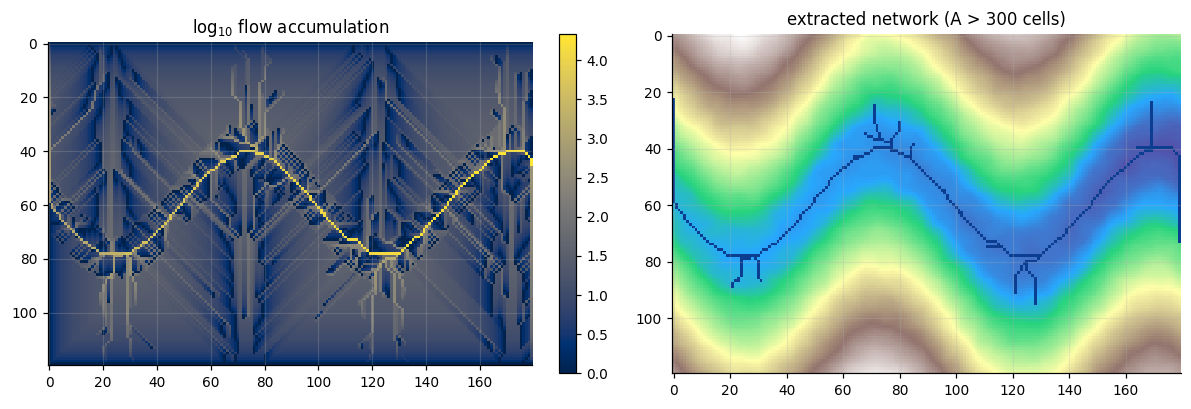

In [9]:
STREAM_THRESHOLD_CELLS = 300                    # tune me (see Section 9)
stream = acc > STREAM_THRESHOLD_CELLS

print(f"threshold  : {STREAM_THRESHOLD_CELLS} cells "
      f"= {STREAM_THRESHOLD_CELLS*CELL_AREA/1e6:.2f} km2")
print(f"river cells: {stream.sum():,}  ({100*stream.mean():.2f} % of domain)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
im = ax[0].imshow(np.log10(acc), cmap="cividis")
ax[0].set_title("log$_{10}$ flow accumulation"); plt.colorbar(im, ax=ax[0], fraction=0.035)
ax[1].imshow(dem, cmap="terrain", alpha=0.85)
ax[1].imshow(np.where(stream, 1, np.nan), cmap=ListedColormap(["#0b3d91"]))
ax[1].set_title(f"extracted network (A > {STREAM_THRESHOLD_CELLS} cells)")
plt.tight_layout(); plt.show()

### 5.5 HAND and the Flood-Prone Area map

Now the core of M1. For every cell we walk downstream along D8 until we hit a river
cell — call it the cell's **nearest drainage**. Then

$$
\mathrm{HAND}_c = z_c - z_{\mathrm{nd}(c)}, \qquad \mathrm{HAND}_c \ge 0 .
$$

The naive implementation re-walks the path for every cell: $O(n \cdot L)$ and
painfully slow. Instead we exploit the topological order again. Process cells
**downstream → upstream** (i.e. `reversed(topo_order)`); by the time we reach cell
$c$, its receiver has already been resolved, so

$$
\mathrm{nd}(c) = \begin{cases}
c & \text{if } c \text{ is a river cell} \\
\mathrm{nd}(\text{receiver}(c)) & \text{otherwise}
\end{cases}
$$

is a single lookup. Total cost: $O(n)$.

The `nd` array is doing double duty. It gives us HAND, **and** it *is* the
**Flood-Prone Area (FPA) map**: all cells sharing the same `nd` value form the FPA
of that river cell. That partition is exactly what TOPFIM's module M2 needs.

In [10]:
def hand_and_fpa(dem, receiver, stream, topo_order):
    """Returns (hand, nd) where nd holds the FLAT INDEX of each cell's
    nearest drainage cell (-1 if the flow path leaves the domain first)."""
    nr, nc = dem.shape
    flat_id = np.arange(nr * nc).reshape(nr, nc)
    nd = np.full((nr, nc), -1, np.int64)

    for (r, c) in reversed(topo_order):              # downstream -> upstream
        if stream[r, c]:
            nd[r, c] = flat_id[r, c]
        else:
            rr, cc = receiver[r, c]
            nd[r, c] = nd[rr, cc] if rr >= 0 else -1

    hand = np.full((nr, nc), np.nan)
    ok = nd >= 0
    hand[ok] = dem[ok] - dem.ravel()[nd[ok]]
    return np.maximum(hand, 0.0), nd            # clip tiny negatives from eps-fill


t0 = time.time()
hand, nd = hand_and_fpa(dem_filled, receiver, stream, topo_order)
print(f"HAND computed in {time.time()-t0:.2f} s")
print(f"HAND range   : {np.nanmin(hand):.2f} - {np.nanmax(hand):.2f} m")
print(f"unresolved   : {(nd < 0).sum():,} cells ({100*(nd<0).mean():.2f} %) "
      f"-- flow paths that exit the domain before reaching a channel")
print(f"distinct FPAs: {len(np.unique(nd[nd >= 0])):,} (= number of river cells)")

HAND computed in 0.03 s
HAND range   : 0.00 - 67.35 m
unresolved   : 0 cells (0.00 %) -- flow paths that exit the domain before reaching a channel
distinct FPAs: 378 (= number of river cells)


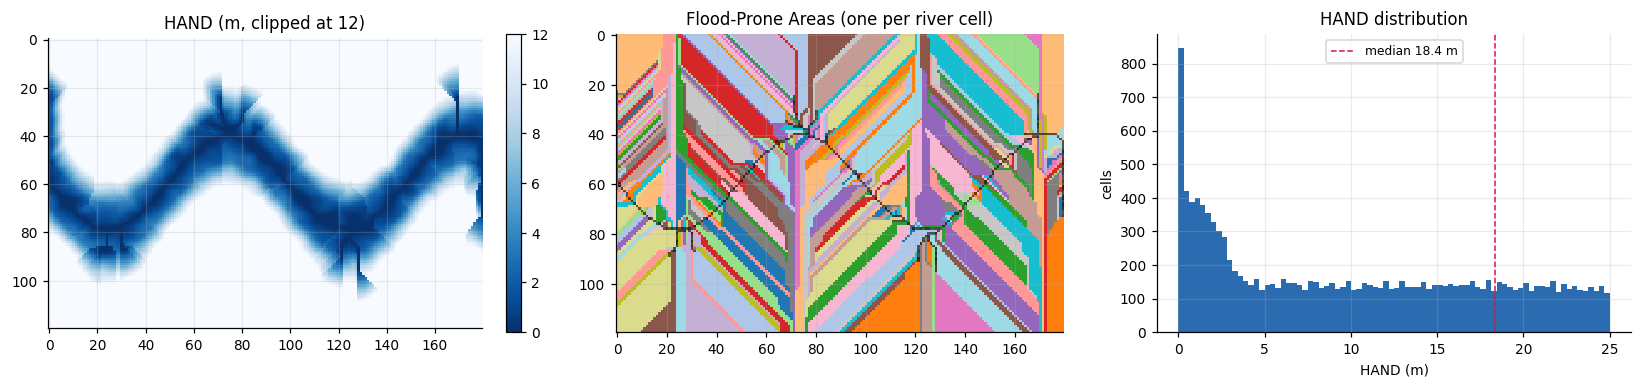

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))

im = ax[0].imshow(np.clip(hand, 0, 12), cmap="Blues_r")
ax[0].set_title("HAND (m, clipped at 12)"); plt.colorbar(im, ax=ax[0], fraction=0.035)

# FPA mosaic: random colours so adjacent catchments are distinguishable
rng = np.random.default_rng(0)
lut = rng.permutation(np.unique(nd[nd >= 0]))
remap = {v: i for i, v in enumerate(lut)}
fpa_img = np.full(nd.shape, np.nan)
ok = nd >= 0
fpa_img[ok] = [remap[v] for v in nd[ok]]
ax[1].imshow(fpa_img, cmap="tab20")
ax[1].imshow(np.where(stream, 1, np.nan), cmap=ListedColormap(["k"]), alpha=0.6)
ax[1].set_title("Flood-Prone Areas (one per river cell)")

h = hand[np.isfinite(hand)]
ax[2].hist(h, bins=80, range=(0, 25), color="#2b6cb0")
ax[2].set_xlabel("HAND (m)"); ax[2].set_ylabel("cells")
ax[2].set_title("HAND distribution")
ax[2].axvline(np.percentile(h, 50), color="crimson", ls="--", lw=1,
              label=f"median {np.percentile(h,50):.1f} m")
ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

> ### 🧪 Exercise 1 — read the HAND histogram
>
> The HAND histogram is usually strongly right-skewed with a sharp spike near zero.
>
> **(a)** Explain the spike physically. Which part of the landscape produces it?
> **(b)** Roughly what fraction of cells has HAND < 3 m? Why does that number,
> rather than the total basin area, set the ceiling on how much water this basin can
> spread out over in a modest flood?
> **(c)** Re-run §5.4–5.5 with `STREAM_THRESHOLD_CELLS = 1000`. Does the median
> HAND go **up** or **down**? Explain the mechanism in one sentence.
>
> *(Hint for (c): with a higher threshold, tributaries are demoted to hillslope, so
> their cells are now referenced to a river that is further away and lower.)*

---
## 6. Module M2 — River Inundation Capacity (RIC)

M1 gave us, for every river cell $i$, the set of hillslope cells it controls:
its flood-prone area $\Omega_i$. M2 asks a simple question about each:

> *If the water surface at this river cell rises by $h_{\rm ref}$ metres, how much
> water can this piece of valley actually hold?*

That number is the **River Inundation Capacity**:

$$
\boxed{\;\mathrm{RIC}_i \;=\; A_c \sum_{c \in \Omega_i} \max\!\left(0,\; h_{\rm ref} - \mathrm{HAND}_c\right) \;}
\qquad [\mathrm{m^3}]
$$

RIC is a **purely topographic** quantity — a storage coefficient of the valley
cross-section, measured at a reference stage. Where the valley is a narrow gorge,
RIC is small; where it opens into a broad floodplain, RIC is large. It is
essentially a HAND-based analogue of the conveyance term you met in open-channel
hydraulics, but for *storage* rather than *discharge*.

> ⚠️ **Operational definition.** The paper introduces RIC as a HAND-based measure
> of a river cell's inundation capacity, used to drive segmentation. The specific
> functional form above (linear storage integral at a fixed reference stage) is
> **this notebook's choice**, selected because it is transparent and directly
> reusable as the SVC in M4. Verify against the paper's equations before citing.

**Choosing $h_{\rm ref}$.** It sets the vertical scale at which you care about
valley shape. Too small and RIC only sees the channel banks; too large and every
cell's RIC saturates to "the whole hillslope", washing out the contrast that
segmentation depends on. A defensible default is roughly the bankfull-to-modest-
flood depth for your basin. We use 2 m and test the sensitivity in Section 9.

In [12]:
def build_fpa_index(hand, nd):
    """river-cell flat index -> 1-D array of HAND values inside its FPA.

    Implemented as a sort-and-split (a 'group-by'), which is far faster than
    looping over river cells and masking the full grid each time.
    """
    valid = (nd >= 0) & np.isfinite(hand)
    keys, vals = nd[valid].ravel(), hand[valid].ravel()
    o = np.argsort(keys, kind="stable")
    keys, vals = keys[o], vals[o]
    uniq, start = np.unique(keys, return_index=True)
    end = np.r_[start[1:], len(keys)]
    return {int(k): vals[s:e] for k, s, e in zip(uniq, start, end)}


def compute_ric(fpa_index, cell_area, h_ref=2.0):
    """RIC_i = A_c * sum_{c in FPA_i} max(0, h_ref - HAND_c)   [m^3]"""
    return {k: float(np.maximum(h_ref - v, 0.0).sum() * cell_area)
            for k, v in fpa_index.items()}


H_REF = 2.0                                   # reference stage for RIC (m)

fpa_index = build_fpa_index(hand, nd)
RIC = compute_ric(fpa_index, CELL_AREA, H_REF)

sizes = np.array([len(v) for v in fpa_index.values()])
vals  = np.array(list(RIC.values()))
print(f"FPAs        : {len(fpa_index):,}")
print(f"FPA size    : median {np.median(sizes):.0f} cells, "
      f"p5-p95 {np.percentile(sizes,5):.0f}-{np.percentile(sizes,95):.0f}")
print(f"RIC @ {H_REF} m : median {np.median(vals):,.0f} m3, "
      f"p5-p95 {np.percentile(vals,5):,.0f}-{np.percentile(vals,95):,.0f} m3")
print(f"RIC contrast: max/min = {vals.max()/max(vals.min(),1):,.1f}x   "
      f"<- this contrast is what makes adaptive segmentation worthwhile")

FPAs        : 378
FPA size    : median 15 cells, p5-p95 1-293
RIC @ 2.0 m : median 5,407 m3, p5-p95 1,800-23,403 m3
RIC contrast: max/min = 76.9x   <- this contrast is what makes adaptive segmentation worthwhile


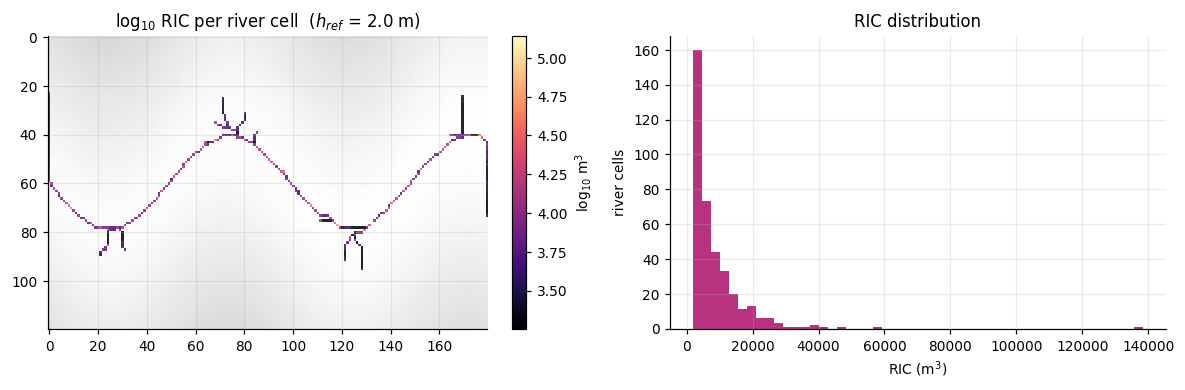

In [13]:
ric_map = np.full(hand.shape, np.nan)
for k, v in RIC.items():
    ric_map.ravel()[k] = v

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
im = ax[0].imshow(np.log10(np.where(ric_map > 0, ric_map, np.nan)), cmap="magma")
ax[0].imshow(dem, cmap="Greys", alpha=0.15)
ax[0].set_title(f"log$_{{10}}$ RIC per river cell  ($h_{{ref}}$ = {H_REF} m)")
plt.colorbar(im, ax=ax[0], fraction=0.035, label="log$_{10}$ m$^3$")

ax[1].hist(vals, bins=50, color="#b83280")
ax[1].set_xlabel("RIC (m$^3$)"); ax[1].set_ylabel("river cells")
ax[1].set_title("RIC distribution")
plt.tight_layout(); plt.show()

> ### 🧪 Exercise 2 — RIC as a landscape reader
>
> **(a)** Locate the highest-RIC river cells on the map. What is special about the
> valley there? Now find the lowest-RIC cells — what is different?
> **(b)** RIC has units of m³, so it scales with FPA size. Compute a
> **normalised** RIC (divide by FPA cell count) to get a mean storage *depth*. Does
> the spatial pattern change? Which version do you think is the better segmentation
> variable, and why?
> **(c)** Recompute RIC with `H_REF = 0.5` and `H_REF = 6.0`. Plot the three RIC
> maps side by side. At which $h_{\rm ref}$ does the along-river contrast collapse,
> and what does that tell you about picking $h_{\rm ref}$ in a real basin?

---
## 7. Module M3 — adaptive river segmentation

### 7.1 Why segment at all?

Two extremes, both wrong:

- **One segment for the whole river.** All cells get the same stage. Headwaters
  drown while the trunk stays dry. This is plain HAND flooding.
- **One segment per river cell.** Each cell gets its own stage. The stage field
  becomes as noisy as the DEM, and you lose the physical idea that a water surface
  is *continuous* along a reach.

TOPFIM's answer is to segment **adaptively**: merge consecutive river cells while
their RIC stays similar, and cut where the valley geometry genuinely changes. So
segment boundaries land at gorge–floodplain transitions and confluences — where a
hydraulic engineer would place a cross-section anyway.

Compare this with fixed-length segmentation (every 500 m, say), which is blind to
geomorphology and will happily average a gorge together with a floodplain.

### 7.2 Step 1 — recover the network topology

The D8 network is a tree of river cells. We split it into **reaches** at
confluences. A reach runs from a headwater (or immediately from a junction) to the
next junction, or to the outlet.

This step matters and is easy to get wrong: the topological order from §5.3 is
*globally* upstream→downstream, but consecutive entries need not be *connected* —
it hops between tributaries. Segmenting along that order would merge cells from
different branches into one segment. So we walk the actual network instead.

In [14]:
def stream_topology(stream, receiver):
    """Returns (downstream, upstream, stream_set) over flat indices."""
    nr, nc = stream.shape
    flat_id = np.arange(nr * nc).reshape(nr, nc)
    idx = [int(flat_id[r, c]) for r, c in zip(*np.where(stream))]
    S = set(idx)
    downstream, upstream = {}, {}
    for f in idx:
        r, c = divmod(f, nc)
        rr, cc = receiver[r, c]
        d = int(flat_id[rr, cc]) if rr >= 0 else -1
        downstream[f] = d if d in S else -1          # -1 = basin outlet
        upstream.setdefault(d, []).append(f)
    return downstream, upstream, S


def extract_reaches(stream, receiver):
    """Split the river tree into reaches at confluences."""
    downstream, upstream, S = stream_topology(stream, receiver)
    n_up = {f: sum(1 for u in upstream.get(f, []) if u in S) for f in S}
    junctions = {f for f in S if n_up[f] >= 2}
    heads     = [f for f in S if n_up[f] == 0]

    reaches, visited = [], set()
    for start in heads + sorted(junctions):
        if start in visited:
            continue
        path, f = [], start
        while f != -1 and f not in visited:
            path.append(f); visited.add(f)
            nxt = downstream[f]
            if nxt == -1 or nxt in visited or nxt in junctions:
                break                                 # a junction starts a new reach
            f = nxt
        if path:
            reaches.append(path)
    assert sum(len(p) for p in reaches) == len(S), "reach decomposition lost cells"
    return reaches, downstream, junctions


reaches, downstream, junctions = extract_reaches(stream, receiver)
print(f"reaches   : {len(reaches)}")
print(f"confluences: {len(junctions)}")
print(f"reach length (cells): median {np.median([len(p) for p in reaches]):.0f}, "
      f"max {max(len(p) for p in reaches)}")
print("partition verified: every river cell belongs to exactly one reach")

reaches   : 29
confluences: 14
reach length (cells): median 9, max 66
partition verified: every river cell belongs to exactly one reach


### 7.3 Step 2 — cut each reach where RIC changes

Walk each reach downstream, keeping a running mean $\bar{R}$ of the RIC of the
cells accumulated so far. Start a new segment when the next cell's RIC falls
outside a multiplicative tolerance band:

$$
\frac{\bar{R}}{1+\tau} \;<\; \mathrm{RIC}_i \;<\; \bar{R}\,(1+\tau)
$$

A **multiplicative** band (rather than additive) is the right choice because RIC
spans orders of magnitude — an absolute tolerance meaningful for the trunk river
would be absurd for a headwater tributary.

Two guards keep the result usable:

- `min_len` — a segment must reach a minimum length before it may be cut, which
  stops single-cell DEM noise from shattering the network;
- `max_len` — a segment is force-cut beyond a maximum length, so a uniform reach
  does not become one enormous segment with an unphysically flat water surface.

> ⚠️ **Operational definition.** The running-mean tolerance rule is this notebook's
> segmentation criterion. The paper's adaptive scheme is RIC-driven in the same
> spirit but may differ in detail.

In [15]:
def segment_reach(path, ric, tol=1.0, min_len=3, max_len=15):
    """Cut one reach into RIC-homogeneous segments."""
    segments, cur, run = [], [], []
    for f in path:
        v = ric.get(f, 0.0)
        if len(cur) >= min_len:
            m = float(np.mean(run))
            outside = m > 0 and not (m / (1 + tol) <= v <= m * (1 + tol))
            if outside or len(cur) >= max_len:
                segments.append(cur); cur, run = [], []
        cur.append(f); run.append(v)
    if cur:                                       # absorb a runt tail
        if segments and len(cur) < min_len:
            segments[-1].extend(cur)
        else:
            segments.append(cur)
    return segments


def segment_network(reaches, ric, tol=1.0, min_len=3, max_len=15):
    return [s for p in reaches for s in segment_reach(p, ric, tol, min_len, max_len)]


SEG_TOL, SEG_MIN, SEG_MAX = 1.0, 3, 15
segments = segment_network(reaches, RIC, SEG_TOL, SEG_MIN, SEG_MAX)

lens = np.array([len(s) for s in segments])
assert sum(lens) == int(stream.sum()), "segmentation lost or duplicated cells"
print(f"segments        : {len(segments)}  (from {stream.sum()} river cells)")
print(f"length (cells)  : median {np.median(lens):.0f}, min {lens.min()}, max {lens.max()}")
print(f"length (m)      : median {np.median(lens)*CELLSIZE:,.0f} m")
print(f"mean cells/seg  : {lens.mean():.1f}")
print("mass check      : every river cell in exactly one segment")

if lens.min() < SEG_MIN:
    print(f"\nNOTE: {(lens < SEG_MIN).sum()} segment(s) are shorter than min_len={SEG_MIN}.")
    print("      These are whole REACHES that were already shorter than min_len --")
    print("      short headwater stubs between confluences. The guard prevents")
    print("      *splitting* below min_len; it cannot lengthen a reach that is")
    print("      genuinely short. This is expected, not a bug.")

segments        : 65  (from 378 river cells)
length (cells)  : median 5, min 1, max 16
length (m)      : median 150 m
mean cells/seg  : 5.8
mass check      : every river cell in exactly one segment

NOTE: 6 segment(s) are shorter than min_len=3.
      These are whole REACHES that were already shorter than min_len --
      short headwater stubs between confluences. The guard prevents
      *splitting* below min_len; it cannot lengthen a reach that is
      genuinely short. This is expected, not a bug.


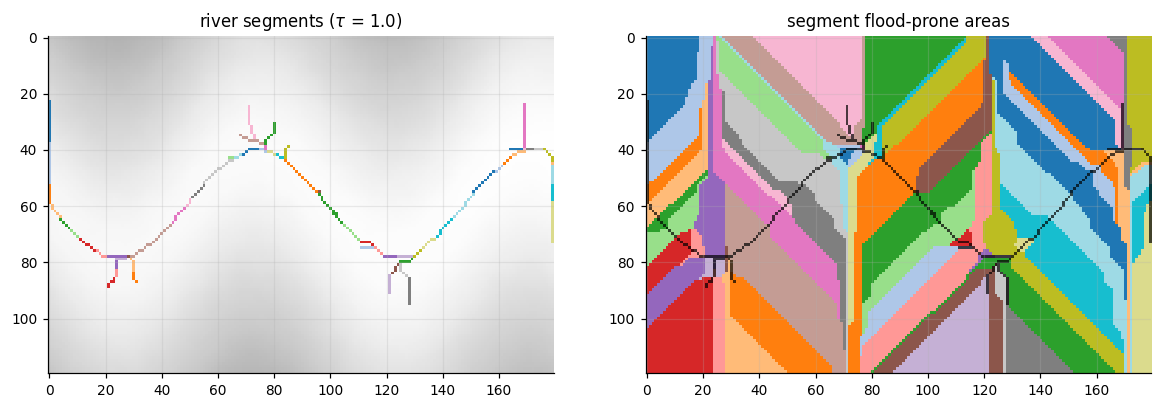

Colours repeat every 20 segments -- adjacent same-colour patches are different segments.


In [16]:
seg_id = np.full(stream.shape, np.nan)
for j, s in enumerate(segments):
    for f in s:
        seg_id.ravel()[f] = j % 20

# each segment's FPA = union of its member river cells' FPAs
seg_of_river = {f: j for j, s in enumerate(segments) for f in s}
seg_fpa_img = np.full(nd.shape, np.nan)
ok = nd >= 0
seg_fpa_img[ok] = [seg_of_river.get(int(v), np.nan) % 20 for v in nd[ok]]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].imshow(dem, cmap="Greys", alpha=0.3)
ax[0].imshow(seg_id, cmap="tab20", vmin=0, vmax=19)
ax[0].set_title(f"river segments ($\\tau$ = {SEG_TOL})")
ax[1].imshow(seg_fpa_img, cmap="tab20", vmin=0, vmax=19)
ax[1].imshow(np.where(stream, 1, np.nan), cmap=ListedColormap(["k"]), alpha=0.7)
ax[1].set_title("segment flood-prone areas")
plt.tight_layout(); plt.show()

print("Colours repeat every 20 segments -- adjacent same-colour patches are "
      "different segments.")

> ### 🧪 Exercise 3 — tune the segmentation
>
> **(a)** Sweep $\tau \in \{0.2, 0.5, 1.0, 2.0, 5.0\}$ and plot the number of
> segments against $\tau$. The curve should look roughly hyperbolic. Where is the
> "elbow", and would you choose your $\tau$ there?
> **(b)** Set `min_len = 1`. How many single-cell segments appear? Explain why
> that is a *modelling* failure and not just an aesthetic one.
> **(c)** Push $\tau \to \infty$ **and** `max_len` to a very large number. The
> segment count stops falling at a floor rather than reaching 1. What sets that
> floor? (Look back at §7.2.) Then explain why TOPFIM still does **not** reduce to
> plain HAND flooding even in this limit — you will meet the true HAND-equivalent
> baseline as `uniform_stage_hand()` in §9.

---
## 8. Module M4 — volume allocation, SVC inversion, and the map

This is where TOPFIM stops being a terrain analysis and becomes a flood model.

### 8.1 Where does the total volume come from?

TOPFIM does not generate water; it *distributes* it. The input $V$ is the flood
volume above bankfull, and in an operational chain it comes from upstream:

$$
V \;=\; \int_{t_0}^{t_1} \max\!\left(0,\; Q(t) - Q_{\rm bankfull}\right)\,\mathrm{d}t
$$

where $Q(t)$ is a forecast hydrograph from a rainfall–runoff or routing model
(VIC, HEC-HMS, an LSTM, the National Water Model, …). That is the coupling point,
and it is also the dominant source of error in practice: a 30 % error in forecast
volume will hurt you far more than any choice of $\tau$.

### 8.2 The allocation weights

We must split $V$ among $N$ segments such that $\sum_j \theta_j = 1$ — this is the
**full water-volume constraint**. Two effects should drive the weights:

1. **Storage capacity.** A segment with a wide floodplain should receive more water
   than one in a gorge → use $\mathrm{RIC}_j = \sum_{i \in j}\mathrm{RIC}_i$.
2. **Position in the network.** A headwater segment carries a small fraction of the
   basin's discharge; the trunk carries nearly all of it. Use upstream contributing
   area $A_j$ as a proxy for that share.

Combined:

$$
w_j \;=\; \mathrm{RIC}_j \cdot \left(\frac{A_j}{A_{\max}}\right)^{\beta},
\qquad
\theta_j \;=\; \frac{w_j}{\sum_k w_k}
$$

- $\beta = 0$ → **capacity-only**: water is spread purely by how much room each
  segment has. Headwaters get flooded as readily as the trunk.
- $\beta = 1$ → **discharge-weighted** (default): the trunk river takes the lion's
  share, which matches how a real flood wave behaves.
- $\beta > 1$ → water concentrates hard on the main stem.

> ⚠️ **Operational definition.** The paper calls its allocation driver the
> **Catchment Inundation Number (CIN)**. The $w_j = \mathrm{RIC}_j (A_j/A_{\max})^\beta$
> form above is this notebook's transparent stand-in, chosen so that the two
> physical effects are separable and $\beta$ gives you a knob to explore. It is
> almost certainly *not* the paper's exact expression. Treat $\beta$ as a
> calibration parameter, and say so if you report results.

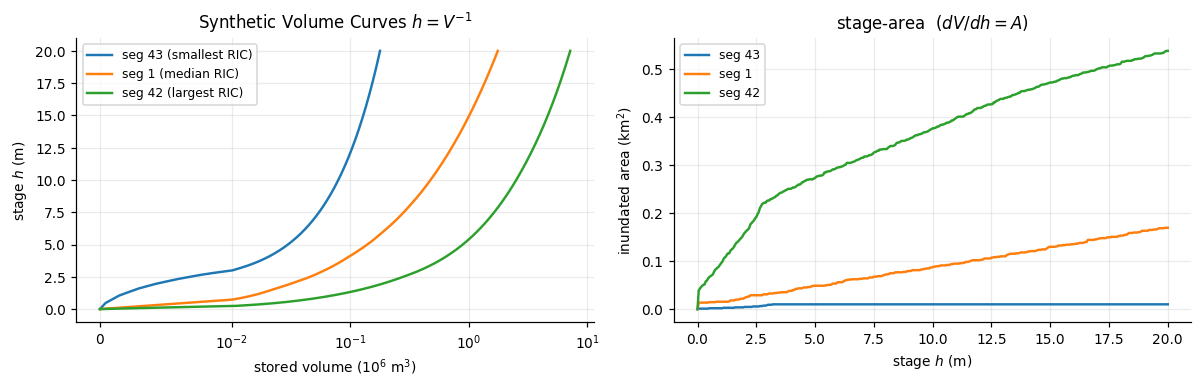

In [17]:
def segment_svc(hand_values, cell_area, h_max=20.0, n=401):
    """Synthetic Volume Curve for one segment.

    Returns (h, V, A):  V(h) = A_c * sum max(0, h - HAND);  A(h) = A_c * #(HAND<h)
    V is non-decreasing by construction, hence invertible.  dV/dh = A(h).
    """
    h = np.linspace(0.0, h_max, n)
    # broadcasting: (n, 1) - (m,) -> (n, m); fine for FPA sizes up to ~1e5
    diff = np.maximum(h[:, None] - hand_values[None, :], 0.0)
    V = diff.sum(axis=1) * cell_area
    A = (hand_values[None, :] < h[:, None]).sum(axis=1) * cell_area
    return h, V, A


def invert_svc(h, V, target_volume):
    """Solve V(h) = target for h by monotone interpolation."""
    if target_volume <= 0:
        return 0.0
    if target_volume >= V[-1]:
        return float(h[-1])                      # saturated: widen h_max
    return float(np.interp(target_volume, V, h))


# --- demonstrate on three contrasting segments -------------------------------
tot_ric = {j: sum(RIC.get(f, 0.0) for f in s) for j, s in enumerate(segments)}
picks = sorted(tot_ric, key=tot_ric.get)
picks = [picks[0], picks[len(picks)//2], picks[-1]]          # small / median / large

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for j, lbl in zip(picks, ["smallest RIC", "median RIC", "largest RIC"]):
    hv = np.concatenate([fpa_index[f] for f in segments[j] if f in fpa_index])
    h, V, A = segment_svc(hv, CELL_AREA)
    ax[0].plot(V / 1e6, h, lw=1.6, label=f"seg {j} ({lbl})")
    ax[1].plot(h, A / 1e6, lw=1.6, label=f"seg {j}")
ax[0].set_xlabel("stored volume (10$^6$ m$^3$)"); ax[0].set_ylabel("stage $h$ (m)")
ax[0].set_title("Synthetic Volume Curves $h = V^{-1}$"); ax[0].legend(fontsize=8)
ax[0].set_xscale("symlog", linthresh=0.01)
ax[1].set_xlabel("stage $h$ (m)"); ax[1].set_ylabel("inundated area (km$^2$)")
ax[1].set_title("stage-area  ($dV/dh = A$)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Read those curves the way you read a rating curve. A **steep** SVC (large $h$ for
small $V$) means a confined valley — a little extra water raises the stage a lot.
A **flat** SVC means a broad floodplain that absorbs volume with barely any rise.
This is precisely the geometric information that a single basin-wide depth
threshold throws away.

In [18]:
def topfim(total_volume, segments, fpa_index, RIC, acc, nd, hand,
           cell_area, beta=1.0, h_max=20.0):
    """Full TOPFIM M4: allocate volume -> invert SVCs -> depth & extent map."""
    accf = acc.ravel()
    a_max = acc.max()

    # --- allocation weights ---------------------------------------------------
    w = np.array([
        sum(RIC.get(f, 0.0) for f in s) * (max(accf[f] for f in s) / a_max) ** beta
        for s in segments
    ], dtype=float)
    if w.sum() <= 0:
        raise ValueError("all allocation weights are zero")
    theta = w / w.sum()                                   # sum(theta) == 1 exactly

    # --- per-segment SVC inversion -------------------------------------------
    depth = np.zeros(hand.shape)
    stage = np.full(len(segments), np.nan)
    saturated = 0
    for j, (s, t) in enumerate(zip(segments, theta)):
        hv = np.concatenate([fpa_index[f] for f in s if f in fpa_index]) \
             if any(f in fpa_index for f in s) else None
        if hv is None or hv.size == 0:
            continue
        h, V, _ = segment_svc(hv, cell_area, h_max=h_max)
        hj = invert_svc(h, V, t * total_volume)
        stage[j] = hj
        if hj >= h_max - 1e-9:
            saturated += 1
        for f in s:                                       # paint this segment's FPA
            m = (nd == f) & (hand < hj)
            depth[m] = hj - hand[m]

    if saturated:
        print(f"  [!] {saturated} segment(s) hit h_max={h_max} m -- increase h_max")
    return depth, stage, theta


TOTAL_VOLUME = 6.0e6        # m3  (from the flood hydrograph -- see 8.1)
BETA = 1.0

t0 = time.time()
depth, stage, theta = topfim(TOTAL_VOLUME, segments, fpa_index, RIC, acc, nd,
                             hand, CELL_AREA, beta=BETA)
runtime = time.time() - t0

wet = depth > 0
V_mapped = depth.sum() * CELL_AREA
print(f"\nruntime          : {runtime:.2f} s")
print(f"inundated cells  : {wet.sum():,}  = {wet.sum()*CELL_AREA/1e6:.2f} km2")
print(f"mean / max depth : {depth[wet].mean():.2f} / {depth.max():.2f} m")
print(f"segment stage    : median {np.nanmedian(stage):.2f} m, "
      f"range {np.nanmin(stage):.2f} - {np.nanmax(stage):.2f} m")
print(f"\nMASS BALANCE")
print(f"  volume in      : {TOTAL_VOLUME:,.0f} m3")
print(f"  volume mapped  : {V_mapped:,.0f} m3")
print(f"  relative error : {100*(V_mapped-TOTAL_VOLUME)/TOTAL_VOLUME:+.4f} %")
print(f"  sum(theta)     : {theta.sum():.10f}")


runtime          : 0.05 s
inundated cells  : 3,143  = 2.83 km2
mean / max depth : 2.12 / 9.27 m
segment stage    : median 1.20 m, range 0.16 - 9.27 m

MASS BALANCE
  volume in      : 6,000,000 m3
  volume mapped  : 5,999,821 m3
  relative error : -0.0030 %
  sum(theta)     : 1.0000000000


**The mass-balance line is the acceptance test for this notebook.** If the relative
error is not a small fraction of a percent, something is wrong — typically a
segment saturating at `h_max`, or an FPA that is empty because its river cell had
no contributing hillslope cells. The residual you *do* see comes from linear
interpolation on the discretised SVC, and shrinks as you increase `n` in
`segment_svc`.

This is the property that plain HAND flooding simply does not have.

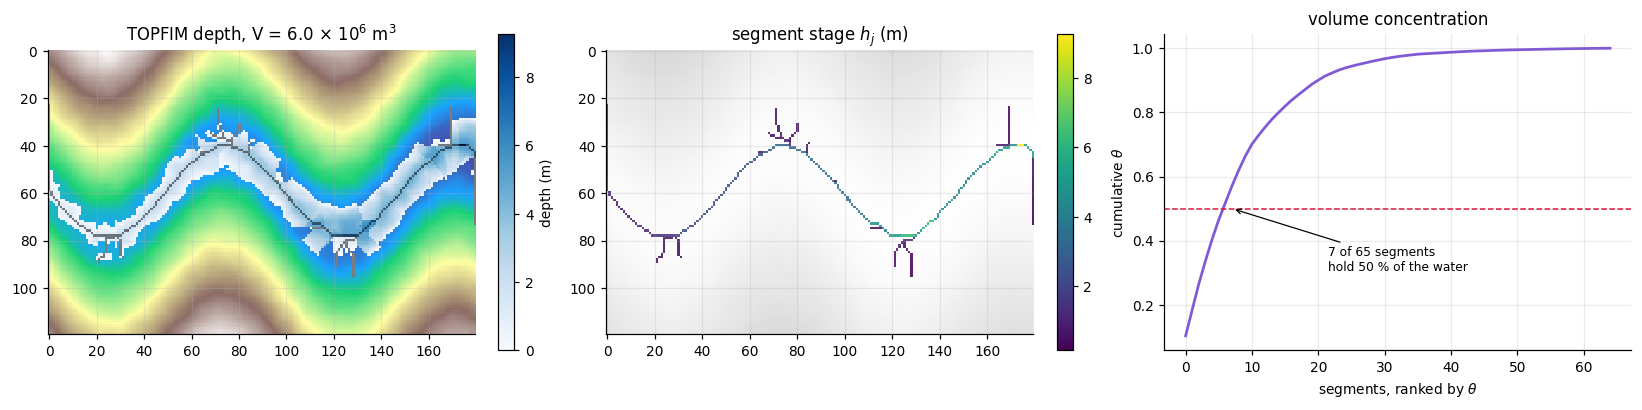

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

ax[0].imshow(dem, cmap="terrain", alpha=0.9)
im = ax[0].imshow(np.where(wet, depth, np.nan), cmap="Blues", vmin=0)
ax[0].imshow(np.where(stream, 1, np.nan), cmap=ListedColormap(["k"]), alpha=0.5)
ax[0].set_title(f"TOPFIM depth, V = {TOTAL_VOLUME/1e6:.1f} $\\times$ 10$^6$ m$^3$")
plt.colorbar(im, ax=ax[0], fraction=0.035, label="depth (m)")

stage_img = np.full(stream.shape, np.nan)
for j, s in enumerate(segments):
    for f in s:
        stage_img.ravel()[f] = stage[j]
im = ax[1].imshow(stage_img, cmap="viridis")
ax[1].imshow(dem, cmap="Greys", alpha=0.15)
ax[1].set_title("segment stage $h_j$ (m)")
plt.colorbar(im, ax=ax[1], fraction=0.035)

order_t = np.argsort(theta)[::-1]
ax[2].plot(np.cumsum(theta[order_t]), lw=1.8, color="#805ad5")
ax[2].set_xlabel("segments, ranked by $\\theta$"); ax[2].set_ylabel("cumulative $\\theta$")
ax[2].set_title("volume concentration")
n50 = int(np.searchsorted(np.cumsum(theta[order_t]), 0.5)) + 1
ax[2].axhline(0.5, color="crimson", ls="--", lw=1)
ax[2].annotate(f"{n50} of {len(segments)} segments\nhold 50 % of the water",
               xy=(n50, 0.5), xytext=(0.35, 0.25), textcoords="axes fraction",
               fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.8))
plt.tight_layout(); plt.show()

> ### 🧪 Exercise 4 — the $\beta$ knob
>
> **(a)** Run the model with $\beta \in \{0, 0.5, 1, 2\}$ at fixed $V$. Plot
> inundated area against $\beta$. Why does the area *decrease* as $\beta$ grows,
> even though the volume is identical?
> **(b)** For each $\beta$, report the fraction of total volume that lands in the
> **top decile** of segments by contributing area. Which $\beta$ looks most like a
> real flood wave to you, and what evidence would you need to settle it?
> **(c)** Doubling $V$ does **not** double the inundated area. Run
> $V \in \{2, 4, 8, 16\} \times 10^6$ m³, fit $A \propto V^{\,p}$ on log–log axes,
> and interpret $p$. What valley geometry would give $p = 1$?

---
## 9. Evaluation — how do you know it worked?

### 9.1 The contingency table

Binary maps are scored cell by cell against a benchmark:

|  | benchmark **wet** | benchmark **dry** |
|---|---|---|
| **model wet** | $A$ hits | $B$ false alarms |
| **model dry** | $C$ misses | $D$ correct negatives |

$$
\mathrm{CSI} = \frac{A}{A+B+C}, \qquad
\mathrm{POD} = \frac{A}{A+C}, \qquad
\mathrm{FAR} = \frac{B}{A+B}, \qquad
\mathrm{Bias} = \frac{A+B}{A+C}
$$

**CSI** (Critical Success Index, a.k.a. threat score / IoU / Jaccard index) is the
headline number because it ignores $D$. That matters: in a large basin the dry area
dwarfs everything else, so plain accuracy $(A+D)/(A+B+C+D)$ would sit near 0.99 for
a model that predicts *nothing is flooded*. Never report accuracy for flood maps.

Read POD and FAR **together with** CSI. A model that floods the entire basin scores
$\mathrm{POD}=1$ and is useless. Bias > 1 means over-prediction, < 1 under.

For context, the TOPFIM paper reports a mean CSI near 0.83 against HEC-RAS on the
Le'an River basin. Published terrain-based FIM studies typically land in the
0.6–0.9 range depending on terrain and benchmark quality.

### 9.2 What to benchmark against

In order of preference:

1. **Observed flood extent** — SAR (Sentinel-1) water masks, optical imagery, or
   surveyed high-water marks. The only true validation.
2. **A calibrated hydrodynamic model** (HEC-RAS 2D, LISFLOOD-FP). This is what the
   TOPFIM paper uses. Strictly this is *benchmarking*, not validation — you are
   measuring agreement with another model, and inheriting its errors.
3. **A simpler terrain model**, to isolate what your added complexity buys.

The cell below runs option 3 as a stand-in so the metrics code is exercised, and
gives you the hook to drop in a real benchmark raster.

In [20]:
def contingency(pred, obs, valid=None):
    """CSI / POD / FAR / bias for two boolean rasters."""
    if valid is None:
        valid = np.ones(pred.shape, bool)
    p = np.asarray(pred, bool)[valid]
    o = np.asarray(obs,  bool)[valid]
    A = int(( p &  o).sum());  B = int(( p & ~o).sum())
    C = int((~p &  o).sum());  D = int((~p & ~o).sum())
    f = lambda num, den: num / den if den else np.nan
    return dict(hits=A, false_alarms=B, misses=C, correct_neg=D,
                CSI=f(A, A + B + C), POD=f(A, A + C),
                FAR=f(B, A + B), bias=f(A + B, A + C))


def uniform_stage_hand(total_volume, hand, fpa_index, cell_area, h_max=30.0):
    """Baseline: ONE global stage h such that total stored volume == V.
    This is classic HAND flooding, made volume-consistent so the comparison
    with TOPFIM is fair (same water, different distribution)."""
    allh = np.concatenate(list(fpa_index.values()))
    h, V, _ = segment_svc(allh, cell_area, h_max=h_max, n=601)
    h0 = invert_svc(h, V, total_volume)
    d = np.where(np.isfinite(hand) & (hand < h0), h0 - hand, 0.0)
    return d, h0


# ---- Benchmark -------------------------------------------------------------
BENCHMARK_PATH = None      # e.g. DATA_DIR / "hecras_maxextent.tif"

if BENCHMARK_PATH is not None and HAS_RASTERIO:
    with rasterio.open(BENCHMARK_PATH) as src:
        benchmark = src.read(1) > 0
    bench_label = "HEC-RAS benchmark"
else:
    depth_u, h_uniform = uniform_stage_hand(TOTAL_VOLUME, hand, fpa_index, CELL_AREA)
    benchmark = depth_u > 0
    bench_label = f"uniform-stage HAND (h = {h_uniform:.2f} m), same volume"
    print(f"No benchmark raster set -- using {bench_label}")
    print("NOTE: this is a MODEL-vs-MODEL comparison. It exercises the metric")
    print("      code and shows what adaptive segmentation changes. It is NOT")
    print("      validation. Set BENCHMARK_PATH to a real map for that.\n")

valid = np.isfinite(hand)
m = contingency(wet, benchmark, valid)
for k in ("CSI", "POD", "FAR", "bias"):
    print(f"  {k:5s} = {m[k]:.3f}")
print(f"  hits {m['hits']:,} | false alarms {m['false_alarms']:,} | misses {m['misses']:,}")

No benchmark raster set -- using uniform-stage HAND (h = 2.95 m), same volume
NOTE: this is a MODEL-vs-MODEL comparison. It exercises the metric
      code and shows what adaptive segmentation changes. It is NOT
      validation. Set BENCHMARK_PATH to a real map for that.

  CSI   = 0.718
  POD   = 0.763
  FAR   = 0.076
  bias  = 0.826
  hits 2,904 | false alarms 239 | misses 900


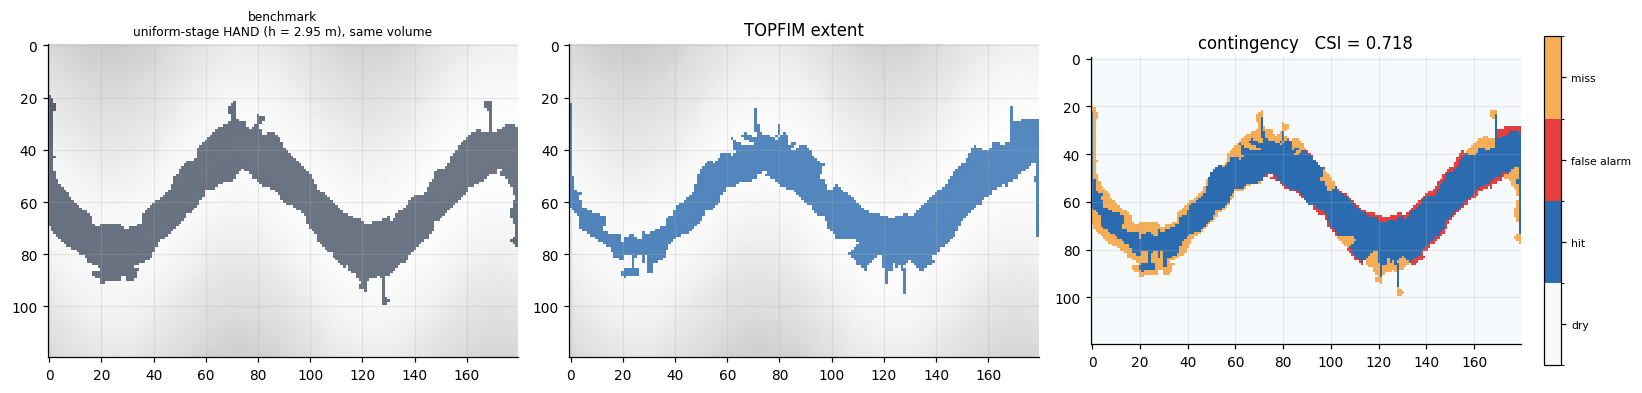

In [21]:
# contingency map: 0 dry, 1 hit, 2 false alarm, 3 miss
cont = np.zeros(wet.shape, np.int8)
cont[ wet &  benchmark] = 1
cont[ wet & ~benchmark] = 2
cont[~wet &  benchmark] = 3
cont_masked = np.where(valid, cont, np.nan)

cmap = ListedColormap(["#f7fafc", "#2b6cb0", "#e53e3e", "#f6ad55"])
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].imshow(np.where(benchmark, 1, np.nan), cmap=ListedColormap(["#4a5568"]))
ax[0].imshow(dem, cmap="Greys", alpha=0.2); ax[0].set_title(f"benchmark\n{bench_label}", fontsize=8)
ax[1].imshow(np.where(wet, 1, np.nan), cmap=ListedColormap(["#2b6cb0"]))
ax[1].imshow(dem, cmap="Greys", alpha=0.2); ax[1].set_title("TOPFIM extent")
im = ax[2].imshow(cont_masked, cmap=cmap, norm=BoundaryNorm([-.5,.5,1.5,2.5,3.5], 4))
ax[2].set_title(f"contingency   CSI = {m['CSI']:.3f}")
cb = plt.colorbar(im, ax=ax[2], fraction=0.035, ticks=[0, 1, 2, 3])
cb.ax.set_yticklabels(["dry", "hit", "false alarm", "miss"], fontsize=7)
plt.tight_layout(); plt.show()

> **How to read a contingency map.** Do not just read the CSI number — look at
> *where* the errors are. Errors ringing the entire flood edge as a thin halo mean
> a small stage bias, which is easy to calibrate away. Errors concentrated in one
> tributary or behind one embankment mean a **structural** problem: a wrong stream
> threshold, a bad allocation weight, or terrain the model fundamentally cannot
> represent. Only the first kind is fixable by tuning.

---
## 10. Sensitivity analysis

A model you have not stress-tested is a model you do not understand. The three
parameters below have very different characters, and knowing which is which is the
practical skill this section is teaching.

In [22]:
def run_pipeline(stream_thr=STREAM_THRESHOLD_CELLS, h_ref=H_REF, tol=SEG_TOL,
                 beta=BETA, volume=TOTAL_VOLUME, verbose=False):
    """Re-run M1(channel)->M4 with modified parameters. Reuses dem_filled/receiver."""
    st = acc > stream_thr
    hd, ndl = hand_and_fpa(dem_filled, receiver, st, topo_order)
    fp = build_fpa_index(hd, ndl)
    rc = compute_ric(fp, CELL_AREA, h_ref)
    rch, _, _ = extract_reaches(st, receiver)
    segs = segment_network(rch, rc, tol, SEG_MIN, SEG_MAX)
    d, sg, th = topfim(volume, segs, fp, rc, acc, ndl, hd, CELL_AREA, beta=beta)
    return dict(depth=d, wet=d > 0, n_seg=len(segs), n_river=int(st.sum()),
                area_km2=(d > 0).sum() * CELL_AREA / 1e6,
                mean_depth=float(d[d > 0].mean()) if (d > 0).any() else np.nan,
                mass_err=100 * (d.sum() * CELL_AREA - volume) / volume)


rows = []
print("--- (1) stream extraction threshold ---")
for thr in [100, 200, 300, 600, 1200]:
    r = run_pipeline(stream_thr=thr)
    rows.append(("A_thr", thr, r))
    print(f"  A_thr={thr:>5}  rivers={r['n_river']:>4}  segs={r['n_seg']:>4}  "
          f"area={r['area_km2']:6.2f} km2  d_mean={r['mean_depth']:5.2f} m  "
          f"mass err {r['mass_err']:+.3f}%")

print("\n--- (2) segmentation tolerance ---")
for tol in [0.2, 0.5, 1.0, 2.0, 5.0]:
    r = run_pipeline(tol=tol)
    rows.append(("tau", tol, r))
    print(f"  tau={tol:>4}    segs={r['n_seg']:>4}  area={r['area_km2']:6.2f} km2  "
          f"d_mean={r['mean_depth']:5.2f} m")

print("\n--- (3) allocation exponent ---")
for b in [0.0, 0.5, 1.0, 2.0]:
    r = run_pipeline(beta=b)
    rows.append(("beta", b, r))
    print(f"  beta={b:>4}   area={r['area_km2']:6.2f} km2  d_mean={r['mean_depth']:5.2f} m")

--- (1) stream extraction threshold ---
  A_thr=  100  rivers= 831  segs= 173  area=  2.70 km2  d_mean= 2.22 m  mass err -0.002%
  A_thr=  200  rivers= 497  segs=  97  area=  2.69 km2  d_mean= 2.23 m  mass err -0.003%


  A_thr=  300  rivers= 378  segs=  65  area=  2.83 km2  d_mean= 2.12 m  mass err -0.003%
  A_thr=  600  rivers= 248  segs=  54  area=  2.84 km2  d_mean= 2.11 m  mass err -0.002%
  A_thr= 1200  rivers= 201  segs=  44  area=  2.83 km2  d_mean= 2.12 m  mass err -0.003%

--- (2) segmentation tolerance ---


  tau= 0.2    segs= 101  area=  2.83 km2  d_mean= 2.12 m
  tau= 0.5    segs=  84  area=  2.84 km2  d_mean= 2.12 m
  tau= 1.0    segs=  65  area=  2.83 km2  d_mean= 2.12 m


  tau= 2.0    segs=  51  area=  2.85 km2  d_mean= 2.11 m
  tau= 5.0    segs=  43  area=  2.84 km2  d_mean= 2.12 m

--- (3) allocation exponent ---
  beta= 0.0   area=  3.40 km2  d_mean= 1.77 m


  beta= 0.5   area=  3.14 km2  d_mean= 1.91 m
  beta= 1.0   area=  2.83 km2  d_mean= 2.12 m
  beta= 2.0   area=  2.45 km2  d_mean= 2.45 m


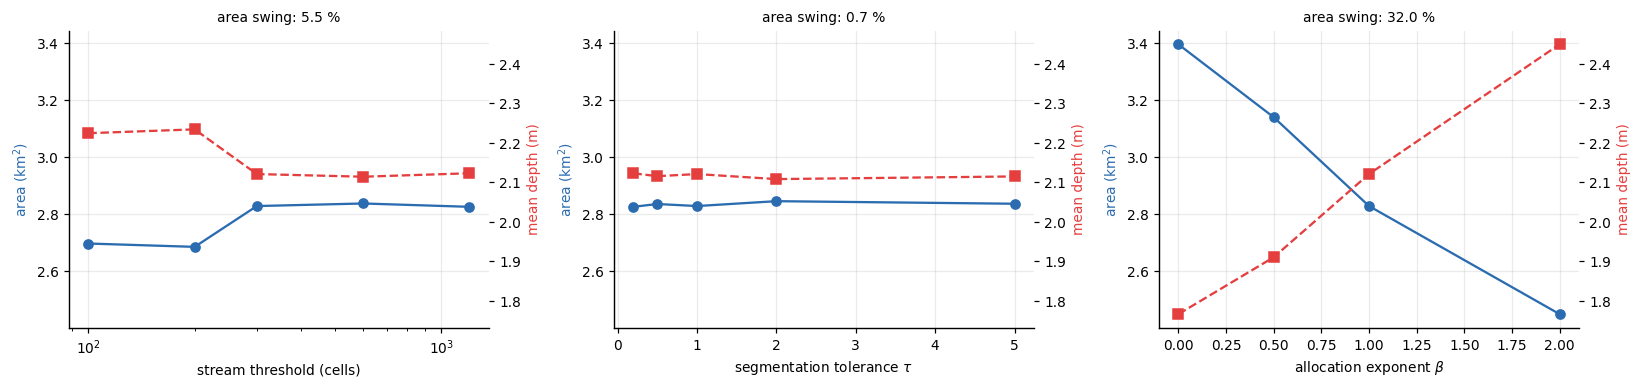

Flat lines are a RESULT, not a plotting failure -- see the discussion below.


In [23]:
# IMPORTANT: all three panels share the SAME y-limits. Autoscaling each panel
# independently would make a 0.7 % wiggle look as dramatic as a 39 % swing --
# a classic way to mislead yourself with your own sensitivity analysis.
allA = [r["area_km2"] for _, _, r in rows]
allD = [r["mean_depth"] for _, _, r in rows]
padA = 0.05 * (max(allA) - min(allA)); padD = 0.05 * (max(allD) - min(allD))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for k, (name, lbl) in enumerate([("A_thr", "stream threshold (cells)"),
                                 ("tau", r"segmentation tolerance $\tau$"),
                                 ("beta", r"allocation exponent $\beta$")]):
    xs = [v for n, v, _ in rows if n == name]
    ys = [r["area_km2"] for n, _, r in rows if n == name]
    ds = [r["mean_depth"] for n, _, r in rows if n == name]
    swing = 100 * (max(ys) - min(ys)) / np.mean(ys)

    ax[k].plot(xs, ys, "o-", color="#2b6cb0", label="inundated area")
    ax[k].set_xlabel(lbl); ax[k].set_ylabel("area (km$^2$)", color="#2b6cb0")
    ax[k].set_ylim(min(allA) - padA, max(allA) + padA)
    ax[k].set_title(f"area swing: {swing:.1f} %", fontsize=9)

    a2 = ax[k].twinx(); a2.plot(xs, ds, "s--", color="#e53e3e", label="mean depth")
    a2.set_ylabel("mean depth (m)", color="#e53e3e"); a2.grid(False)
    a2.set_ylim(min(allD) - padD, max(allD) + padD)
    if name == "A_thr":
        ax[k].set_xscale("log")
plt.tight_layout(); plt.show()

print("Flat lines are a RESULT, not a plotting failure -- see the discussion below.")

### What the sweeps should tell you

Read your own numbers before reading this paragraph, then check whether you agree.

- **$\beta$ (allocation exponent)** is by far the strongest lever on this basin: it
  trades **area against depth at constant volume**, and the swing is large. That is
  as it should be — it is the only parameter that decides *where* the water goes,
  and it is a genuine physical choice rather than a numerical one. It is therefore
  the parameter most in need of calibration against observations, and the one you
  are obliged to report.
- **$\tau$ (segmentation tolerance)** barely moves the extent at all, even though it
  changes the segment count by a factor of two or more. This is reassuring: total
  extent is governed by how much water there is and what shape the valley has, and
  moving segment boundaries only redistributes it locally.
- **$A_{\rm thr}$ (stream threshold)** restructures the network dramatically — river
  cell and segment counts move by a factor of four — yet the extent moves little
  **in this basin**. Do not over-generalise from that. This synthetic catchment has
  a single dominant valley, so promoting or demoting tributaries barely changes
  where water *can* go. In a real dendritic basin, where tributary floodplains hold
  a meaningful share of the storage, $A_{\rm thr}$ can matter a great deal. Part C
  of the assignment asks you to test exactly this.

The general lesson is worth more than any of the three: **a parameter that visibly
restructures your model internals is not automatically a parameter that changes your
answer.** Sweep and measure; do not assume. And where a mapped river network exists,
pin $A_{\rm thr}$ against it rather than tuning it to the flood outcome — tuning the
network to the answer is circular.

Notice what is *not* here: **Manning's $n$**, channel slope, bed roughness, culvert
geometry. TOPFIM contains no hydraulic resistance at all. That is the source of both
its speed and its limitations.

---
## 11. Limitations — when to put TOPFIM down and open HEC-RAS

Be able to argue this section in a viva. Knowing where a model breaks is worth more
than knowing how to run it.

**1. Depth is much less reliable than extent.** Every cell in a segment shares one
stage $h_j$, so the water surface is a staircase of horizontal facets. The TOPFIM
authors say this themselves: simplified models of this family have limited skill for
inundation *depth* within the floodplain. Report extent metrics (CSI/POD/FAR) with
confidence; report depth errors with humility.

**2. No momentum → no backwater, no supercritical flow, no hydraulic jumps.** At a
tributary confluence, a bridge contraction, or upstream of a weir, the real water
surface tilts and can rise metres above the horizontal-surface assumption. Terrain
methods cannot see this.

**3. Steady-state in time.** TOPFIM maps a volume, not a wave. It gives you no
arrival time, no rate of rise, no drawdown, no attenuation. If your question is
*"when does the water reach the hospital?"* rather than *"how far does it get?"*,
this is the wrong tool.

**4. It inherits every DEM error.** Bare-earth quality is everything. Vegetation
returns, unmapped embankments and missing culverts all propagate straight into HAND
and then into the map. The paper's own comparison of 5 m against 30 m DEMs on the
Le'an basin exists precisely because this dominates.

**5. Flat terrain breaks D8.** In deltas, tidal plains and heavily engineered
landscapes, the "nearest drainage" of a cell can be hydrologically meaningless.
Much of the lower Indo-Gangetic and Brahmaputra plain falls in this category — a
serious caveat for anyone applying HAND-family methods on the Indian subcontinent.

**6. No hydraulic structures.** Levees, embankments, barrages, gates, pumps,
detention basins — none exist unless they happen to be in the DEM as topography,
and even then their *operation* is invisible.

**7. Pluvial and coastal flooding are out of scope.** TOPFIM is a fluvial model. It
distributes river water over a valley. Urban drainage surcharge and storm surge need
different physics entirely.

**Where it does shine:** rapid basin- to national-scale screening; ensemble
forecasting where you need hundreds of realisations; data-scarce basins with no
calibrated hydraulic model; generating training data or priors for machine-learning
surrogates; and pre-computing a stage–extent library so that an operational forecast
becomes a table lookup.

---
## 12. Assignment

**Deliverable:** one executed `.ipynb` plus a 2-page PDF summary. Work individually.

### Part A — reproduce and verify (25 marks)
Run the notebook end to end. Report the mass-balance error and explain, in your own
words, *why* it is non-zero and what single change would shrink it. Then increase
`n` in `segment_svc` and demonstrate the effect quantitatively.

### Part B — real data (30 marks)
Download the TOPFIM archive from Figshare (§4.1) **or** build a basin of your own
from open DEMs (Copernicus GLO-30, NASADEM, or CartoDEM / Bhuvan for Indian basins).
Document CRS, resolution, vertical datum and NoData handling. Run M1–M4. Show the
DEM, network, HAND, FPA and final depth map with proper scale bars and north arrows.

### Part C — sensitivity and calibration (25 marks)
Produce a $5 \times 4$ grid over $(A_{\rm thr}, \beta)$ and report CSI for each
combination against a benchmark of your choosing (a SAR water mask is ideal —
Sentinel-1 GRD via the Copernicus Data Space is free). Identify the optimum,
and — this is the marked part — argue whether that optimum is **physically
meaningful** or merely a fit to one event.

### Part D — critique (20 marks)
Pick **one** Indian river reach you know something about (Kosi, Brahmaputra,
Godavari, Mahanadi, Beas, Sutlej, …). In 500 words, argue for or against deploying
TOPFIM there operationally. Cite at least two of the limitations in §11 and give
concrete local evidence — embankment networks, braiding, tidal influence, DEM
availability, gauge density.

### Marking notes
- Figures without axis labels, units or scale bars lose marks.
- A negative result, honestly diagnosed, scores **higher** than a good number you
  cannot explain.
- If you use an LLM to help write code, say so and state what you verified yourself.

---
## 13. References and further reading

**Primary source**

- Shi, P., *et al.* (2025). A Novel Topography-Based Approach for Real-Time Flood
  Inundation Mapping. *Water Resources Research*, 61, e2024WR037851.
  <https://doi.org/10.1029/2024WR037851>
- Shi, P. (2024). *The code and data for TOPFIM* [Dataset]. figshare.
  <https://doi.org/10.6084/m9.figshare.25687194>

**HAND and terrain-based FIM**

- Rennó, C. D., *et al.* (2008). HAND, a new terrain descriptor using SRTM-DEM.
  *Remote Sensing of Environment*, 112(9), 3469–3481.
- Nobre, A. D., *et al.* (2011). Height Above the Nearest Drainage — a
  hydrologically relevant new terrain model. *Journal of Hydrology*, 404(1–2), 13–29.
- Zheng, X., *et al.* (2018). River channel geometry and rating curve estimation
  using height above the nearest drainage. *JAWRA*, 54(4), 785–806.
- Johnson, J. M., Munasinghe, D., Eyelade, D., & Cohen, S. (2019). An integrated
  evaluation of the National Water Model (NWM)–HAND flood mapping methodology.
  *NHESS*, 19, 2405–2420.
- Thalakkottukara, N. T., *et al.* (2024). Suitability of the HAND model for flood
  inundation mapping in data-scarce regions. *Earth Science Informatics*.

**Terrain algorithms**

- Barnes, R., Lehman, C., & Mulla, D. (2014). Priority-Flood: an optimal
  depression-filling and watershed-labeling algorithm. *Computers & Geosciences*,
  62, 117–127.
- O'Callaghan, J. F., & Mark, D. M. (1984). The extraction of drainage networks
  from digital elevation data. *CVGIP*, 28(3), 323–344.
- Tarboton, D. G. (1997). A new method for the determination of flow directions and
  upslope areas in grid DEMs. *Water Resources Research*, 33(2), 309–319.

**Context and evaluation**

- Teng, J., *et al.* (2017). Flood inundation modelling: a review of methods, recent
  advances and uncertainty analysis. *Environmental Modelling & Software*, 90, 201–216.
- Wing, O. E. J., *et al.* (2017). Validation of a 30 m resolution flood hazard model
  of the conterminous United States. *Water Resources Research*, 53, 7968–7986.
- Bates, P. D. (2022). Flood inundation prediction. *Annual Review of Fluid
  Mechanics*, 54, 287–315.

**Production-grade tooling (do not reimplement in anger)**

- `pysheds`, `richdem`, `WhiteboxTools`, `TauDEM` — DEM hydrology
- NOAA-OWP `inundation-mapping` — operational HAND-FIM: <https://github.com/NOAA-OWP/inundation-mapping>
- `fimeval` — FIM evaluation framework: <https://github.com/sdmlua/fimeval>

---

*Prepared by **Siddik**, HIMPACT Lab, IIT Mandi. Questions and corrections are
welcome — especially corrections. If you find that one of the boxes marked
⚠️ Operational definition disagrees with the published equations, tell me and I
will fix the notebook.*